In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import  accuracy_score, f1_score, precision_score,confusion_matrix, recall_score, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn import metrics
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

In [2]:

from google.colab import files

uploaded = files.upload()

Saving creditcard_2023.csv to creditcard_2023.csv


In [3]:

df = pd.read_csv('creditcard_2023.csv')
print(df.head(7))

   id        V1        V2        V3        V4        V5        V6        V7  \
0   0 -0.260648 -0.469648  2.496266 -0.083724  0.129681  0.732898  0.519014   
1   1  0.985100 -0.356045  0.558056 -0.429654  0.277140  0.428605  0.406466   
2   2 -0.260272 -0.949385  1.728538 -0.457986  0.074062  1.419481  0.743511   
3   3 -0.152152 -0.508959  1.746840 -1.090178  0.249486  1.143312  0.518269   
4   4 -0.206820 -0.165280  1.527053 -0.448293  0.106125  0.530549  0.658849   
5   5  0.025302 -0.140514  1.191138 -0.707979  0.430490  0.458973  0.611050   
6   6  1.016482 -0.397181  0.497868 -0.144463  0.331022  0.629243  0.431262   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0 -0.130006  0.727159  ... -0.110552  0.217606 -0.134794  0.165959  0.126280   
1 -0.133118  0.347452  ... -0.194936 -0.605761  0.079469 -0.577395  0.190090   
2 -0.095576 -0.261297  ... -0.005020  0.702906  0.945045 -1.154666 -0.605564   
3 -0.065130 -0.205698  ... -0.146927 -0.038212 

In [4]:
print(df.tail())
print(df['Class'].value_counts())

            id        V1        V2        V3        V4        V5        V6  \
568625  568625 -0.833437  0.061886 -0.899794  0.904227 -1.002401  0.481454   
568626  568626 -0.670459 -0.202896 -0.068129 -0.267328 -0.133660  0.237148   
568627  568627 -0.311997 -0.004095  0.137526 -0.035893 -0.042291  0.121098   
568628  568628  0.636871 -0.516970 -0.300889 -0.144480  0.131042 -0.294148   
568629  568629 -0.795144  0.433236 -0.649140  0.374732 -0.244976 -0.603493   

              V7        V8        V9  ...       V21       V22       V23  \
568625 -0.370393  0.189694 -0.938153  ...  0.167503  0.419731  1.288249   
568626 -0.016935 -0.147733  0.483894  ...  0.031874  0.388161 -0.154257   
568627 -0.070958 -0.019997 -0.122048  ...  0.140788  0.536523 -0.211100   
568628  0.580568 -0.207723  0.893527  ... -0.060381 -0.195609 -0.175488   
568629 -0.347613 -0.340814  0.253971  ...  0.534853 -0.291514  0.157303   

             V24       V25       V26       V27       V28    Amount  Class  
5686

In [5]:
df.shape

(568630, 31)

In [6]:
df.columns

Index(['id', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

In [8]:
df.value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
id,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,
568629,-0.795144,0.433236,-0.649140,0.374732,-0.244976,-0.603493,-0.347613,-0.340814,0.253971,-0.513556,0.892136,-1.153011,0.489197,-1.062488,0.207773,-0.917240,-0.936114,-0.823688,-0.330408,-0.621378,0.534853,-0.291514,0.157303,0.931030,-0.349423,-1.090974,-1.575113,0.722936,21493.92,1,1
0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,0.637735,-0.987020,0.293438,-0.941386,0.549020,1.804879,0.215598,0.512307,0.333644,0.124270,0.091202,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0,1
1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,0.529808,0.140107,1.564246,0.574074,0.627719,0.706121,0.789188,0.403810,0.201799,-0.340687,-0.233984,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0,1
2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,0.690708,-0.272985,0.659201,0.805173,0.616874,3.069025,-0.577514,0.886526,0.239442,-2.366079,0.361652,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0,1
3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,0.575231,-0.752581,0.737483,0.592994,0.559535,-0.697664,-0.030669,0.242629,2.178616,-1.345060,-0.378223,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25,-0.428662,-0.486577,1.335370,-0.445397,0.374992,-0.104685,0.638620,-0.175984,0.803562,0.664018,-1.231271,0.508368,-0.594977,0.563241,-0.272542,0.282101,0.444203,0.030756,0.207159,-0.566283,-0.268654,-0.248598,0.760981,0.844933,0.326500,0.613009,0.202286,0.486727,6152.06,0,1
26,0.969820,-0.327822,0.620581,-0.168847,0.188500,-0.077233,0.568531,-0.225049,0.352323,0.578896,-0.697335,1.468732,1.586615,0.758007,0.864835,0.456716,0.288346,0.119670,-0.558587,-0.134505,-0.076414,0.169936,-0.174608,0.923436,1.138396,-0.807538,-0.219081,-0.027485,12276.67,0,1
27,1.095337,-0.505013,0.706601,-0.377971,-0.031331,-0.023858,0.346771,-0.201778,-0.063383,1.032537,-1.056683,0.547979,0.444596,0.799296,0.891190,-0.136810,0.372485,1.404627,-1.352772,-0.711489,-0.219092,-0.333443,-0.061867,0.735651,0.852656,-0.662075,-0.189088,-0.030431,13658.07,0,1


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,568630.0,2.843145e+05,164149.486121,0.000000,142157.250000,284314.500000,426471.750000,568629.000000
V1,568630.0,-5.638058e-17,1.000001,-3.495584,-0.565286,-0.093638,0.832658,2.229046
V2,568630.0,-1.319545e-16,1.000001,-49.966572,-0.486678,-0.135894,0.343555,4.361865
V3,568630.0,-3.518788e-17,1.000001,-3.183760,-0.649299,0.000353,0.628538,14.125834
V4,568630.0,-2.879008e-17,1.000001,-4.951222,-0.656020,-0.073762,0.707005,3.201536
V5,568630.0,7.997245e-18,1.000001,-9.952786,-0.293496,0.081088,0.439737,42.716891
V6,568630.0,-3.958636e-17,1.000001,-21.111108,-0.445871,0.078718,0.497788,26.168402
V7,568630.0,-3.198898e-17,1.000001,-4.351839,-0.283533,0.233366,0.525955,217.873038
V8,568630.0,2.109273e-17,1.000001,-10.756342,-0.192257,-0.114524,0.047299,5.958040
V9,568630.0,3.998623e-17,1.000001,-3.751919,-0.568745,0.092526,0.559262,20.270062


In [10]:
df['Class'].unique()


array([0, 1])

In [11]:
df[df.duplicated()].count()


,0
id,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [12]:
df.isna().sum()

,0
id,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


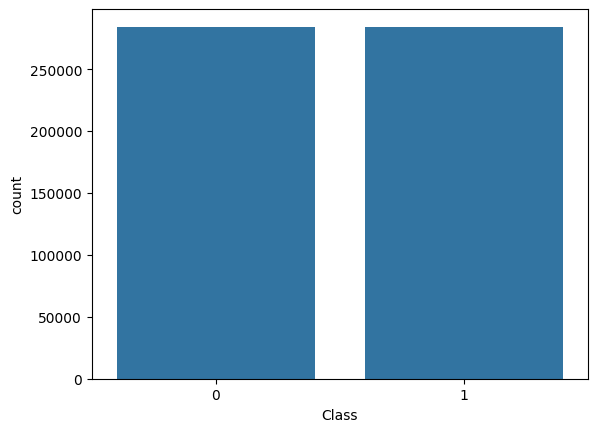

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
sns.countplot(data=df, x='Class')

plt.savefig("equlib.jpg", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("equlib.jpg")

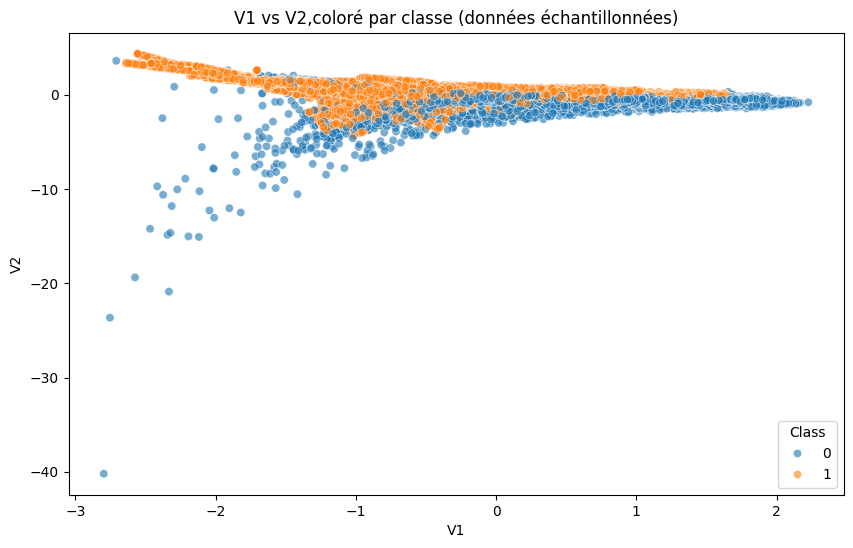

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
df.shape
plt.figure(figsize=(10, 6))
sns.scatterplot(x='V1', y='V2', hue='Class', data=df.sample(frac=0.1, random_state=42), alpha=0.6)
plt.title('V1 vs V2,coloré par classe (données échantillonnées)')

plt.savefig("V1_V2.jpg", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("V1_V2.jpg")

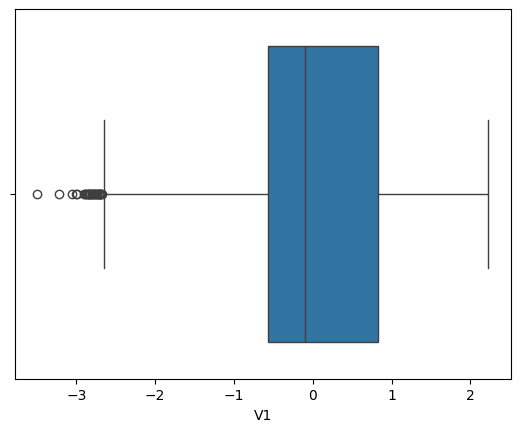

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
sns.boxplot(df, x="V1")

plt.savefig("box.jpg", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("box.jpg")

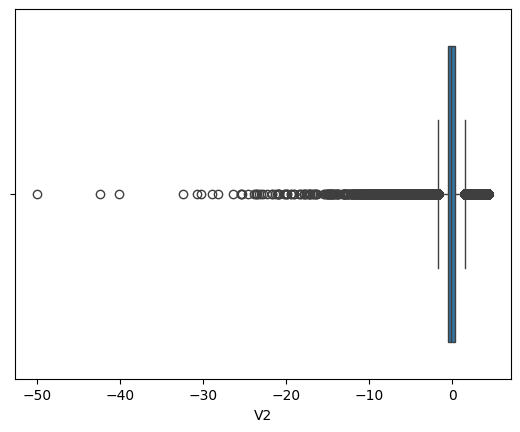

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
sns.boxplot(df, x="V2")

plt.savefig("box2.jpg", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("box2.jpg")

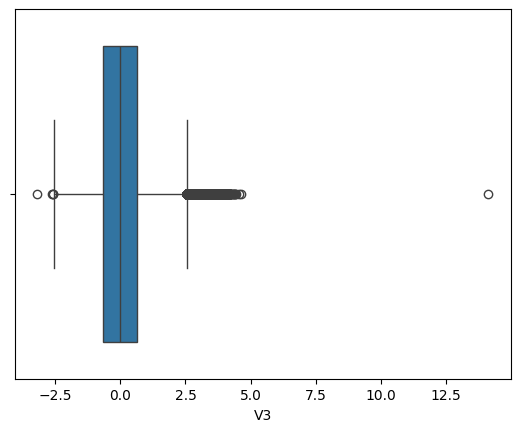

In [17]:
sns.boxplot(df, x="V3")
plt.show();

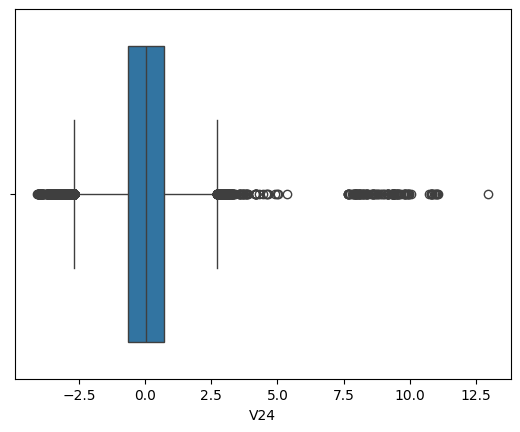

In [18]:
sns.boxplot(df, x="V24")
plt.show();

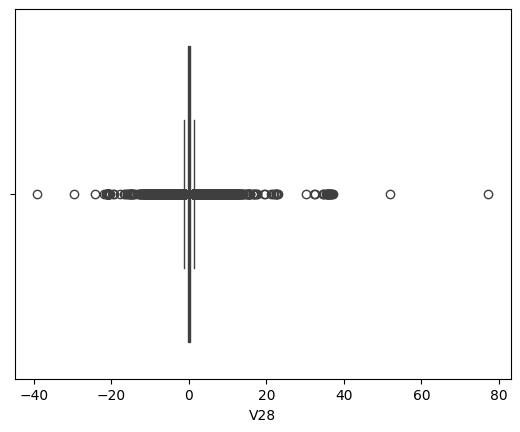

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
sns.boxplot(df, x="V28")
plt.savefig("box28.jpg", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("box28.jpg")

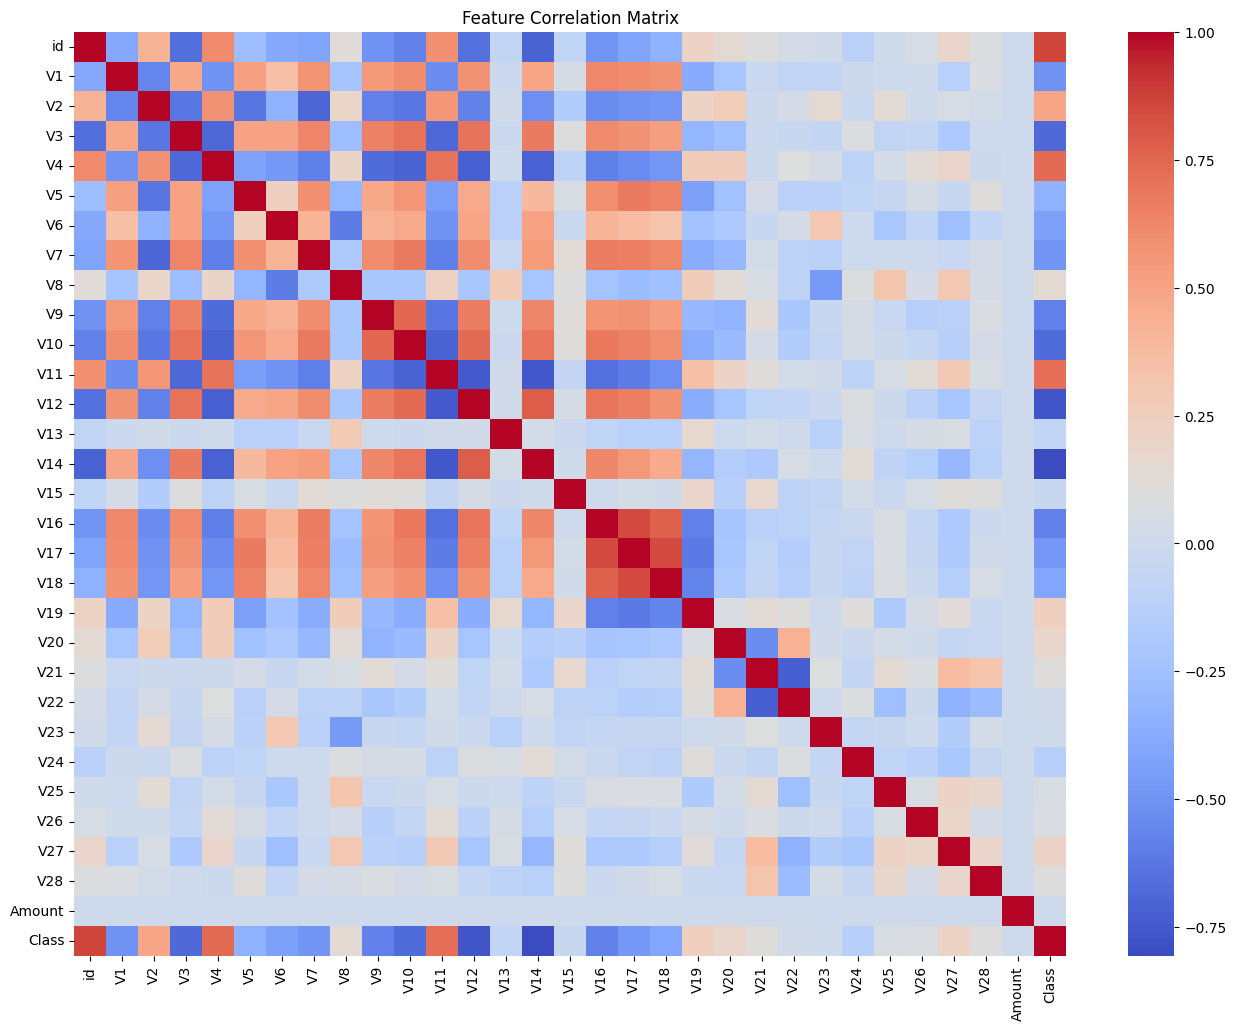

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:

correlation_matrix = df.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title("Feature Correlation Matrix")
plt.savefig("corr.jpg", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("corr.jpg")


In [21]:

df = df.drop(['id'], axis=1)

In [22]:
X = df.drop(columns=['Class'])
y = df["Class"]

In [23]:

seed = 42
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state = seed)



In [24]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=1,
    max_samples=0.7,
    bootstrap=True
)

In [25]:
param_grid = {
    'n_estimators': [20, 50],
    'max_depth': [5, 10]
}

In [26]:
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=2,
    scoring='accuracy',
    n_jobs=1,
    verbose=2
)

In [27]:
grid_rf.fit(X_train, y_train)
print("Meilleur paramètre :", grid_rf.best_params_)
print("Meilleur score CV :", grid_rf.best_score_)

best_model = grid_rf.best_estimator_
y_pred = best_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print("Rapport de classification :")

Fitting 2 folds for each of 4 candidates, totalling 8 fits
[CV] END .......................max_depth=5, n_estimators=20; total time=  13.3s
[CV] END .......................max_depth=5, n_estimators=20; total time=  13.5s
[CV] END .......................max_depth=5, n_estimators=50; total time=  33.4s
[CV] END .......................max_depth=5, n_estimators=50; total time=  33.4s
[CV] END ......................max_depth=10, n_estimators=20; total time=  24.7s
[CV] END ......................max_depth=10, n_estimators=20; total time=  24.7s
[CV] END ......................max_depth=10, n_estimators=50; total time= 1.0min
[CV] END ......................max_depth=10, n_estimators=50; total time= 1.0min
Meilleur paramètre : {'max_depth': 10, 'n_estimators': 20}
Meilleur score CV : 0.9845923535515186
[[56639   111]
 [ 1591 55385]]
Rapport de classification :


In [28]:
mse_test = MSE(y_test, y_pred)
print(mse_test)

0.014965794980919052


In [29]:
rmse_test = MSE(y_test, y_pred)**(1/2)
print(' RMSE  {:.2f}'.format(rmse_test))

 RMSE  0.12


In [30]:
y_pred = best_model.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

Accuracy : 0.9850342050190809
Precision : 0.9979998558454664
Recall : 0.9720759618084808
F1-score : 0.9848673447613628


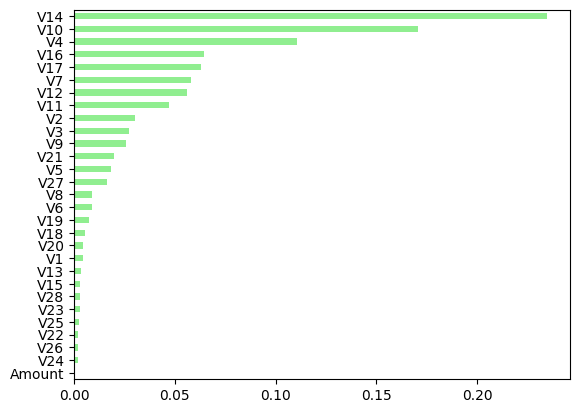

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
best_rf = grid_rf.best_estimator_
importances_rf = pd.Series(
    best_rf.feature_importances_,
    index=X.columns)
sorted_importances_rf = importances_rf.sort_values()
sorted_importances_rf.plot(kind='barh', color='lightgreen')
plt.savefig("distv.jpg", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("distv.jpg")


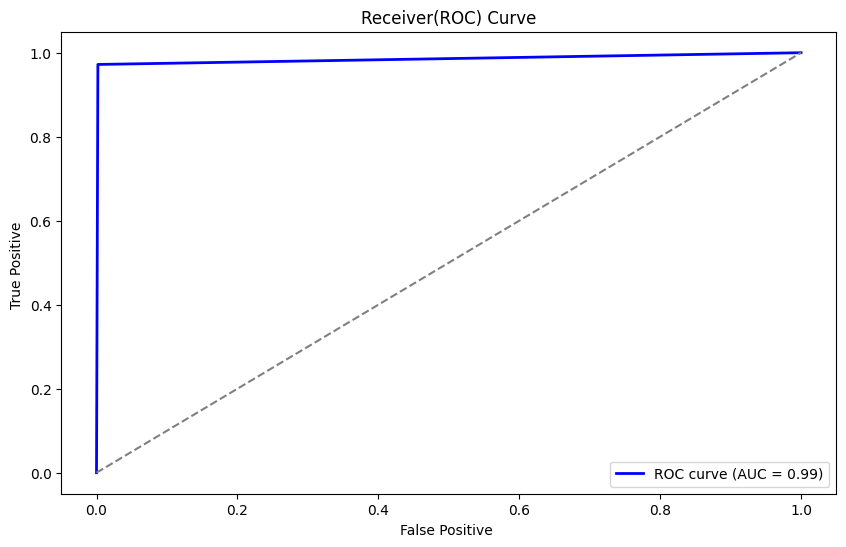

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:

y_probs = best_model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive ')
plt.ylabel('True Positive ')
plt.title('Receiver(ROC) Curve')
plt.legend(loc='lower right')
plt.savefig("roc.jpg", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("roc.jpg")

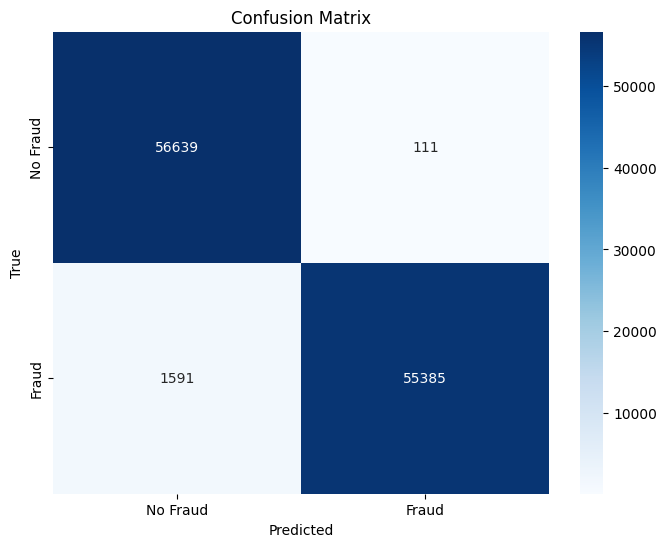

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig("conf.jpg", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("conf.jpg")

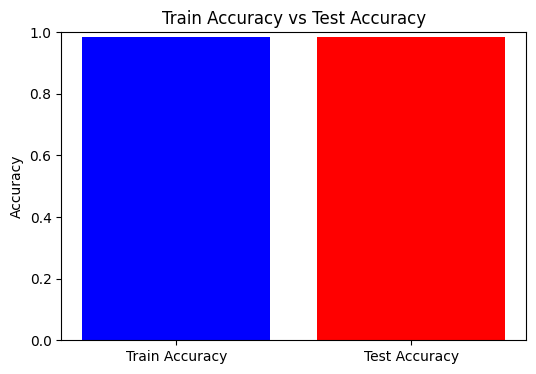

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
train_accuracy = accuracy_score(y_test, y_pred)
test_accuracy = accuracy_score(y_test, y_pred)
plt.figure(figsize=(6, 4))
accuracy_values = [train_accuracy, test_accuracy]
accuracy_labels = ['Train Accuracy', 'Test Accuracy']
plt.bar(accuracy_labels, accuracy_values, color=['blue', 'red'])
plt.ylabel('Accuracy')
plt.title('Train Accuracy vs Test Accuracy')
plt.ylim(0, 1)
plt.savefig("acufor.jpg", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("acufor.jpg")

In [35]:


random_forest = grid_rf.best_estimator_
TOP_N = 20
mdi_importances = random_forest.feature_importances_
mdi_sorted_idx = np.argsort(mdi_importances)[-TOP_N:]

result = permutation_importance(
    random_forest,
    X_train,
    y_train,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importances = result.importances_mean
perm_sorted_idx = np.argsort(perm_importances)[-TOP_N:]



/tmp/ipykernel_28568/2306619657.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(


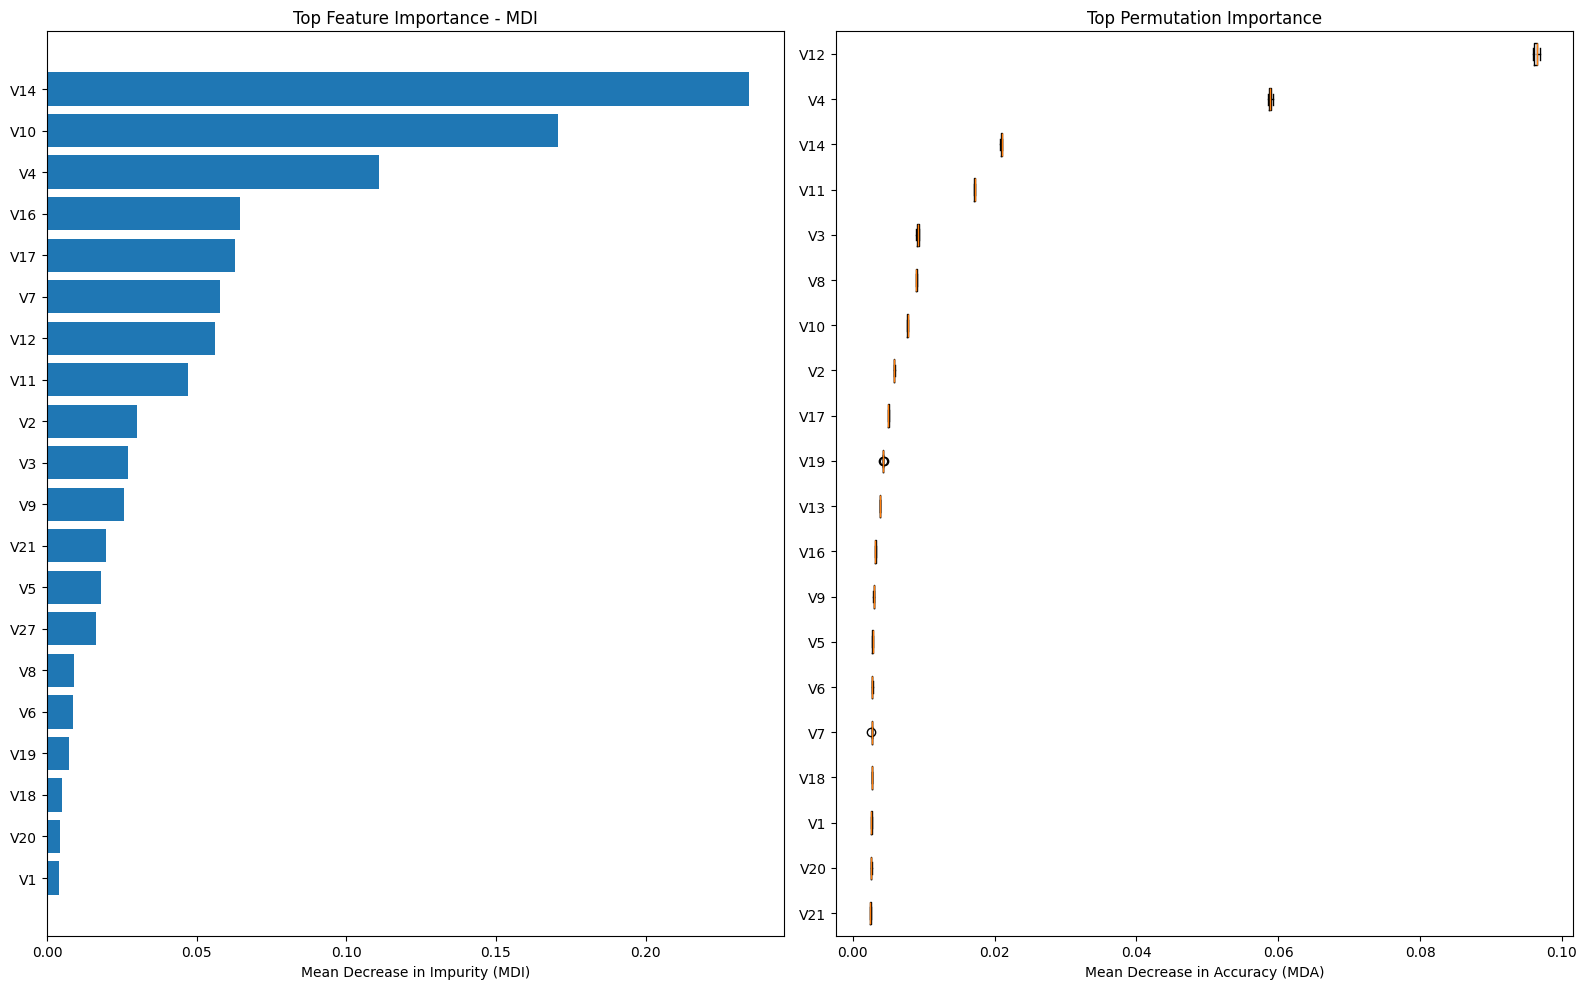

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))


ax1.barh(
    range(len(mdi_sorted_idx)),
    mdi_importances[mdi_sorted_idx]
)

ax1.set_yticks(range(len(mdi_sorted_idx)))
ax1.set_yticklabels(X_train.columns[mdi_sorted_idx])
ax1.set_xlabel("Mean Decrease in Impurity (MDI)")
ax1.set_title("Top Feature Importance - MDI")

ax2.boxplot(
    result.importances[perm_sorted_idx].T,
    vert=False,
    labels=X_train.columns[perm_sorted_idx]
)

ax2.set_xlabel("Mean Decrease in Accuracy (MDA)")
ax2.set_title("Top Permutation Importance")

plt.tight_layout()
plt.savefig("bb.jpg", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("bb.jpg")

In [37]:
param_grid_xgb = {
    'n_estimators': [20, 50],
    'max_depth': [5, 10]
    }

xgb = XGBClassifier(
    random_state=123,
    objective='binary:logistic'
    )
CV_xgb = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=2,
    scoring='accuracy',
    n_jobs=1,
    verbose=2
)

In [38]:

le = LabelEncoder()
y_train = le.fit_transform(y_train)

y_test = le.fit_transform(y_test)

In [39]:

model_xgb = CV_xgb.fit(X_train, y_train)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
[CV] END .......................max_depth=5, n_estimators=20; total time=  12.9s
[CV] END .......................max_depth=5, n_estimators=20; total time=  13.0s
[CV] END .......................max_depth=5, n_estimators=50; total time=  31.9s
[CV] END .......................max_depth=5, n_estimators=50; total time=  32.7s
[CV] END ......................max_depth=10, n_estimators=20; total time=  24.6s
[CV] END ......................max_depth=10, n_estimators=20; total time=  24.4s
[CV] END ......................max_depth=10, n_estimators=50; total time= 1.0min
[CV] END ......................max_depth=10, n_estimators=50; total time= 1.0min


In [40]:
CV_xgb.get_params

<bound method BaseEstimator.get_params of GridSearchCV(cv=2,
             estimator=RandomForestClassifier(max_samples=0.7, n_jobs=1,
                                              random_state=42),
             n_jobs=1,
             param_grid={'max_depth': [5, 10], 'n_estimators': [20, 50]},
             scoring='accuracy', verbose=2)>

In [41]:

model_xgb = XGBClassifier(
    n_estimators=500,
    random_state=123,
    objective='binary:logistic',
    max_depth=6,
    colsample_bylevel=1,
    colsample_bytree=1,
    min_child_weight=3,
    learning_rate=0.01,
    reg_lambda=1,
    min_split_loss=0.2,
    reg_alpha=0)

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

print("Accuracy xgboost {:0.2f}%.".format(accuracy_score(y_test, y_pred_xgb) * 100))

Accuracy xgboost 98.90%.


In [42]:
roc_xgb = roc_auc_score(y_test, y_pred_xgb)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

model_results_xgb = pd.DataFrame([['Xgboost', acc_xgb, prec_xgb, rec_xgb, f1_xgb, roc_xgb]],
                              columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC'])
model_results_xgb

,Model,Accuracy,Precision,Recall,F1 Score,ROC
0,Xgboost,0.988956,0.992627,0.985275,0.988937,0.988963


[[56333   417]
 [  839 56137]]


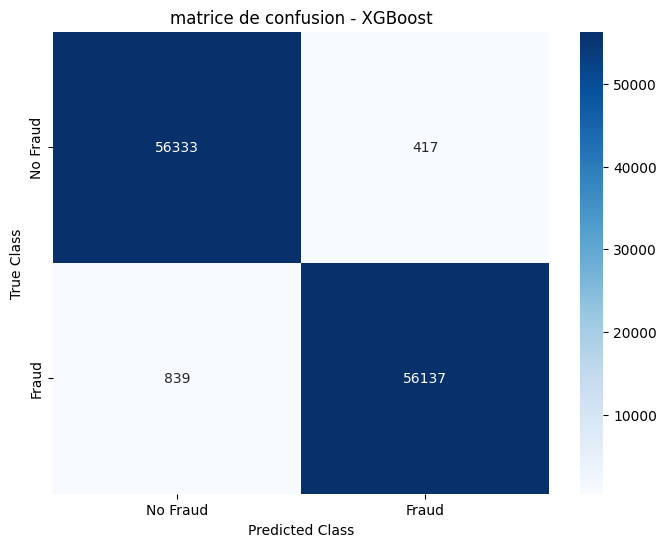

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
print(matrix_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(matrix_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.title('matrice de confusion - XGBoost')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.savefig("confxg.jpg", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("confxg.jpg")

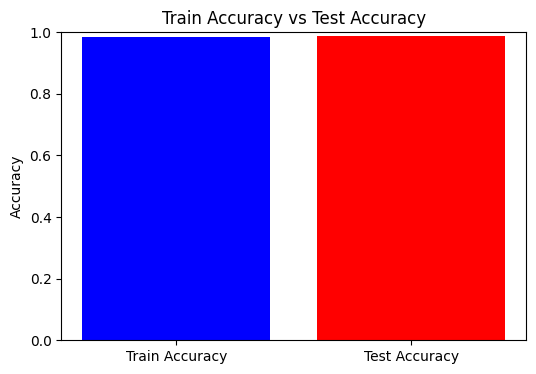

In [44]:
train_accuracy = accuracy_score(y_test, y_pred)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
accuracy_values = [train_accuracy, acc_xgb]
accuracy_labels = ['Train Accuracy', 'Test Accuracy']
plt.bar(accuracy_labels, accuracy_values, color=['blue', 'red'])
plt.ylabel('Accuracy')
plt.title('Train Accuracy vs Test Accuracy')
plt.ylim(0, 1)
plt.show();